In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/functions/query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


17030
17030


In [2]:

llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: True, Database: mondial


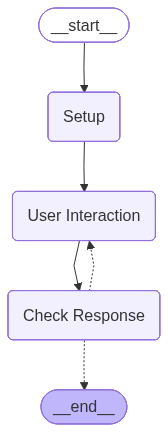

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [4]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    # Invoca a avaliação com as configurações estendidas
    eval_result = eval_graph.invoke({
        "experiment": experiment,
        "max_retries": 2,
        "debug_mode": True,
        "model_version": model_version,
        "experiment_type": experiment_type
    })

    print("Experimento avaliado:\n", eval_result["experiment_eval"])

    # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
    evals.append({
        "experiment_id": exp_id,
        "experiment_config": eval_result.get("experiment_config", {
            "max_retries": 2,
            "model_version": model_version,
            "timestamp": datetime.now().isoformat(),
            "experiment_type": experiment_type
        }),
        "experiment_eval": eval_result["experiment_eval"]
    })

    # Atualiza o arquivo salvando o resultado atual
    with open(evals_filename, 'w', encoding='utf-8') as f:
        json.dump(evals, f, indent=4)

Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  What is the depth of the Mediterranean Sea?
Decomposition
['What is the depth of the Mediterranean Sea?', 'Qual é a profundidade do Mar Mediterrâneo?']
(17030,)
(17030,)
DFE
Question: What are the depths of the Baltic Sea and Marmara Sea?
SELECT NAME, DEPTH FROM MONDIAL_SEA WHERE LOWER(NAME) IN ('baltic sea', 'marmara sea')

Question: Baltic Sea Marmara Sea depths
SELECT NAME, DEPTH FROM MONDIAL_SEA WHERE LOWER(NAME) IN ('baltic sea', 'marmara sea')

Question: What are the depths of the seas in the MONDIAL_SEA table?
SELECT NAME, DEPTH FROM MONDIAL_SEA

Question: What is the total length of borders where there is information about the depth of the sea?
SELECT SUM(MONDIAL_BORDERS.LENGTH)
FROM MONDIAL_BORDERS
WHERE MONDIAL_BORDERS.COUNTRY1 IN (
    SELECT MONDIAL_GEO_SEA.COUNTRY
    FROM MONDIAL_GEO_SEA
    WHERE MO

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "What is the depth of the Mediterranean Sea?",
    "schema_linking": ["mondial_gpt.sea"],
    "answer": "The depth of the Mediterranean Sea is 5267 meters.",
    "sql": "SELECT name, depth FROM mondial_gpt.sea WHERE LOWER(name) = LOWER('Mediterranean Sea')"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What is the depth of the Mediterranean Sea?",
    "schema_linking": ["mondial_gpt.sea"],
    "answer": "The depth of the Mediterranean Sea is 5267 meters.",
    "sql": "SELECT name, depth FROM mondial_gpt.sea WHERE LOWER(name) = LOWER('Mediterranean Sea')"
}.

[INFO] Avaliando o resultado: {'input': 'What is the depth of the Mediterranean Sea?', 'schema_linking': ['mondial_gpt.sea'], 'answer': 'The depth of the Mediterranean Sea is 5267 meters.', 'sql': "SELECT name, depth FROM mondial_gpt.sea WHERE LOWER(name) = LOWER('Mediterranean Sea')"}.

[AI as J

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['DEPTH'], dtype='object')
Adj. True cols: Index(['DEPTH'], dtype='object')
Predicted cols: Index(['NAME', 'DEPTH'], dtype='object')
Adj. Predicted cols: Index(['DEPTH'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'What is the depth of the Mediterranean Sea?', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'What is the depth of the Mediterranean Sea?', 'agent_reply': 'The depth of the Mediterranean Sea is 5267 meters.', 'evaluation': {'text_to_sql_input': 'What is the depth of the Mediterranean Sea?', 'user_intention': 'What is the depth of the Mediterranean Sea?', 'recall': 0.0, 'alignment': True, 'correctness': True, 'expected_sql': "SELECT DEPTH FROM MONDIAL_SEA WHERE NAME = 'Mediterranean Sea'", 'generated_sql': "SELECT name, depth FROM mondial_gpt.sea WHERE LOWER(name) = LOWER('Mediterranean Sea')", 'is_retry': False, 'retry_count': 0, 'retry_reason': None, 'execution_time':

...

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


Decomposition
['What is the inflation rate of Greece?', 'Qual é a taxa de inflação da Grécia?']
(17030,)
(17030,)
DFE
Question: Which countries have an inflation rate of 1.9 or 3.4, and are also listed as Monaco, Greece, or Denmark in the country names?
SELECT MONDIAL_ECONOMY.COUNTRY
FROM MONDIAL_ECONOMY
JOIN MONDIAL_COUNTRY ON MONDIAL_ECONOMY.COUNTRY = MONDIAL_COUNTRY.NAME
WHERE MONDIAL_ECONOMY.INFLATION IN (1.9, 3.4)
AND LOWER(MONDIAL_COUNTRY.NAME) IN ('monaco', 'greece', 'denmark')

Question: countries high inflation rate over 5%
SELECT COUNTRY 
FROM MONDIAL_ECONOMY 
WHERE INFLATION > 5

Question: Which countries in the MONDIAL_ECONOMY table have an inflation rate of 1.9 or 3.4, and are also listed in the MONDIAL_COUNTRY table as Monaco, Greece, or Denmark?
SELECT MONDIAL_ECONOMY.COUNTRY
FROM MONDIAL_ECONOMY
JOIN MONDIAL_COUNTRY ON MONDIAL_ECONOMY.COUNTRY = MONDIAL_COUNTRY.NAME
WHERE MONDIAL_ECONOMY.INFLATION IN (1.9, 3.4)
AND LOWER(MONDIAL_COUNTRY.NAME) IN ('monaco', 'greece', 'den

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/pandas/io/sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "What is the inflation rate of Greece?",
    "schema_linking": ["economy", "country"],
    "answer": "I encountered an error while fetching the inflation rate of Greece. Could you please rephrase your question for better clarity?",
    "sql": "SELECT e.inflation"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What is the inflation rate of Greece?",
    "schema_linking": ["economy", "country"],
    "answer": "I encountered an error while fetching the inflation rate of Greece. Could you please rephrase your question for better clarity?",
    "sql": "SELECT e.inflation"
}.

[INFO] Avaliando o resultado: {'input': 'What is the inflation rate of Greece?', 'schema_linking': ['economy', 'country'], 'answer': 'I encountered an error while fetching the inflation rate of Greece. Could you please rephrase your question for better clarity?', 'sql': 'SELECT e.infl

KeyboardInterrupt: 